Random Forest Model


=== 30-Day Readmission ===
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      2022
           1       0.85      0.82      0.84      2063

    accuracy                           0.84      4085
   macro avg       0.84      0.84      0.84      4085
weighted avg       0.84      0.84      0.84      4085



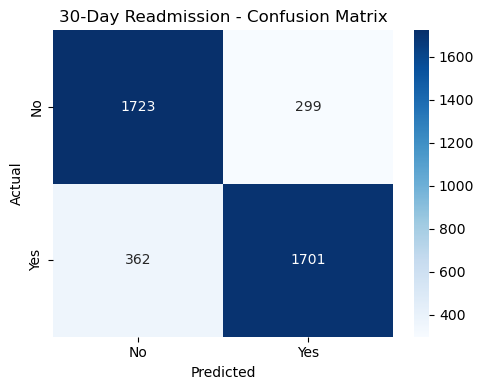


=== 60-Day Readmission ===
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1857
           1       0.85      0.83      0.84      2228

    accuracy                           0.83      4085
   macro avg       0.82      0.83      0.83      4085
weighted avg       0.83      0.83      0.83      4085



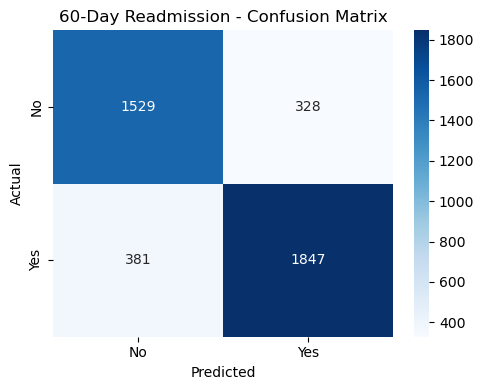

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("readmission_dataset.csv")

# Shared features (exclude targets)
features = df.columns.difference(["readmitted_30_days", "readmitted_60_days"])

# Normalize numeric features
numeric_cols = df[features].select_dtypes(include=["float64", "int64"]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Function to train and evaluate model
def train_and_evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n=== {label} Readmission ===")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{label} Readmission - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Train and evaluate both models
X_all = df[features]

train_and_evaluate(X_all, df["readmitted_30_days"], "30-Day")
train_and_evaluate(X_all, df["readmitted_60_days"], "60-Day")


Logistic Regression Model

In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- Load Dataset ---
df = pd.read_csv("readmission_dataset.csv")

# --- Define features and targets ---
features = df.columns.difference(["readmitted_30_days", "readmitted_60_days"])
X = df[features]
y_30 = df["readmitted_30_days"]
y_60 = df["readmitted_60_days"]

# --- Normalize numeric features ---
numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# --- Split dataset for 30-day model ---
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(X, y_30, test_size=0.2, random_state=42)

# --- Train logistic regression model for 30-day readmission ---
lr_30 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_30.fit(X_train_30, y_train_30)
y_pred_30 = lr_30.predict(X_test_30)

# --- Evaluate 30-day model ---
print("=== 30-Day Readmission ===")
print(classification_report(y_test_30, y_pred_30))
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_30))
print("ROC AUC Score:", roc_auc_score(y_test_30, lr_30.predict_proba(X_test_30)[:, 1]))

# --- Split dataset for 60-day model ---
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(X, y_60, test_size=0.2, random_state=42)

# --- Train logistic regression model for 60-day readmission ---
lr_60 = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_60.fit(X_train_60, y_train_60)
y_pred_60 = lr_60.predict(X_test_60)

# --- Evaluate 60-day model ---
print("\n=== 60-Day Readmission ===")
print(classification_report(y_test_60, y_pred_60))
print("Confusion Matrix:\n", confusion_matrix(y_test_60, y_pred_60))
print("ROC AUC Score:", roc_auc_score(y_test_60, lr_60.predict_proba(X_test_60)[:, 1]))


=== 30-Day Readmission ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      2022
           1       0.76      0.82      0.79      2063

    accuracy                           0.78      4085
   macro avg       0.78      0.78      0.78      4085
weighted avg       0.78      0.78      0.78      4085

Confusion Matrix:
 [[1475  547]
 [ 364 1699]]
ROC AUC Score: 0.84814555641698

=== 60-Day Readmission ===
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1857
           1       0.80      0.82      0.81      2228

    accuracy                           0.79      4085
   macro avg       0.78      0.78      0.78      4085
weighted avg       0.79      0.79      0.79      4085

Confusion Matrix:
 [[1389  468]
 [ 405 1823]]
ROC AUC Score: 0.8509197572579468


/var/folders/d4/n8k1334n6v910lgvrxcfdjfw0000gn/T/ipykernel_4361/3722058212.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
